In [72]:
import sys
from pathlib import Path
from pyprojroot import here

sys.path.append(str(here()))

In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import cfg
from src.utils import set_seed

In [74]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [75]:
gseed = cfg.general.seed
set_seed(gseed)

In [76]:
train_path = Path(cfg.paths.train)
test_path = Path(cfg.paths.test)

In [77]:
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

### first look

In [78]:
df_train.shape

(1460, 81)

In [79]:
df_test.shape

(1459, 80)

In [80]:
df_train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [81]:
df_train.sample(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1054,1055,60,RL,90.0,11367,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,11,2006,WD,Normal,255000
361,362,50,RL,NaN,9144,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2008,WD,Normal,145000
1282,1283,20,RL,61.0,8800,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,150500
161,162,60,RL,110.0,13688,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2008,WD,Normal,412500
515,516,20,RL,94.0,12220,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,New,Partial,402861
555,556,45,RM,58.0,6380,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2006,WD,Normal,113000
1450,1451,90,RL,60.0,9000,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,136000
1364,1365,160,FV,30.0,3180,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,144152
327,328,20,RL,80.0,11600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2006,WD,Normal,145250
779,780,90,RL,78.0,10530,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2006,WD,Normal,135000


In [82]:
df_test.sample(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
416,1877,20,RL,65.0,10739,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2009,WD,Normal
300,1761,20,RL,115.0,10500,Pave,NaN,IR1,Lvl,AllPub,...,92,0,NaN,NaN,NaN,0,7,2009,COD,Abnorml
21,1482,120,RL,41.0,7132,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
261,1722,20,RL,63.0,13072,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,8,2009,WD,Normal
956,2417,20,RL,68.0,7942,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal
1239,2700,120,RL,50.0,7175,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1028,2489,20,RL,91.0,11375,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,10,2007,WD,Normal
301,1762,60,RL,NaN,8970,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,6,2009,WD,Normal
1074,2535,60,RL,NaN,12728,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,1,2007,WD,Normal
797,2258,20,RL,NaN,9556,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal


In [83]:
set(df_train.columns) - set(df_test.columns)  # целевая колонка

{'SalePrice'}

### info

In [84]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [85]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   str    
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   str    
 6   Alley          107 non-null    str    
 7   LotShape       1459 non-null   str    
 8   LandContour    1459 non-null   str    
 9   Utilities      1457 non-null   str    
 10  LotConfig      1459 non-null   str    
 11  LandSlope      1459 non-null   str    
 12  Neighborhood   1459 non-null   str    
 13  Condition1     1459 non-null   str    
 14  Condition2     1459 non-null   str    
 15  BldgType       1459 non-null   str    
 16  HouseStyle     1459 non-null   str    
 17  OverallQual    1459 non-null   int64  
 18  OverallCond    1459

In [86]:
df_train.describe()


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [87]:
df_test.describe()


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1459.000000,1459.000000,1232.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1444.000000,1458.000000,...,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,2190.000000,57.378341,68.580357,9819.161069,6.078821,5.553804,1971.357779,1983.662783,100.709141,439.203704,...,472.768861,93.174777,48.313914,24.243317,1.794380,17.064428,1.744345,58.167923,6.104181,2007.769705
std,421.321334,42.746880,22.376841,4955.517327,1.436812,1.113740,30.390071,21.130467,177.625900,455.268042,...,217.048611,127.744882,68.883364,67.227765,20.207842,56.609763,30.491646,630.806978,2.722432,1.301740
min,1461.000000,20.000000,21.000000,1470.000000,1.000000,1.000000,1879.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,1825.500000,20.000000,58.000000,7391.000000,5.000000,5.000000,1953.000000,1963.000000,0.000000,0.000000,...,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,2190.000000,50.000000,67.000000,9399.000000,6.000000,5.000000,1973.000000,1992.000000,0.000000,350.500000,...,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,2554.500000,70.000000,80.000000,11517.500000,7.000000,6.000000,2001.000000,2004.000000,164.000000,753.500000,...,576.000000,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,2919.000000,190.000000,200.000000,56600.000000,10.000000,9.000000,2010.000000,2010.000000,1290.000000,4010.000000,...,1488.000000,1424.000000,742.000000,1012.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


In [88]:
df_train.describe(include=["str"])

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


In [89]:
df_test.describe(include=["str"])

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1455,1459,107,1459,1459,1457,1459,1459,1459,1459,...,1383,1381,1381,1381,1459,3,290,51,1458,1459
unique,5,2,2,4,4,1,5,3,25,9,...,6,3,4,5,3,2,4,3,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
freq,1114,1453,70,934,1311,1457,1081,1396,218,1251,...,853,625,1293,1328,1301,2,172,46,1258,1204


### duplicates

In [90]:
df_train.duplicated().sum()

np.int64(0)

In [91]:
df_test.duplicated().sum()

np.int64(0)

### unique

In [92]:
data = []
all_in_train_flag = True
for col in df_test.columns:
    data.append(
        {
            "col:": col,
            "train_nunique": df_train[col].nunique(),
            "test_nunique": df_train[col].nunique(),
            "dtype": df_train[col].dtype,
        }
    )

df_data = pd.DataFrame(data)
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(df_data)

,col:,train_nunique,test_nunique,dtype
0,Id,1460,1460,int64
1,MSSubClass,15,15,int64
2,MSZoning,5,5,str
3,LotFrontage,110,110,float64
4,LotArea,1073,1073,int64
5,Street,2,2,str
6,Alley,2,2,str
7,LotShape,4,4,str
8,LandContour,4,4,str
9,Utilities,2,2,str


In [93]:
missing_categories = {}

for col in df_test.columns:
    if df_train[col].dtype == "str":
        train_unique = set(df_train[col])
        test_unique = set(df_test[col])

        diff = test_unique - train_unique

        if diff:
            missing_categories[col] = diff

In [94]:
for col, values in missing_categories.items():
    print(
        f"Столбец '{col}': {len(values)} новых значений -> {values}"
    )  # новых значений категориальных признаков в train нет

Столбец 'MSZoning': 1 новых значений -> {nan}
Столбец 'Utilities': 1 новых значений -> {nan}
Столбец 'Exterior1st': 1 новых значений -> {nan}
Столбец 'Exterior2nd': 1 новых значений -> {nan}
Столбец 'KitchenQual': 1 новых значений -> {nan}
Столбец 'Functional': 1 новых значений -> {nan}
Столбец 'SaleType': 1 новых значений -> {nan}


In [95]:
df_train["SalePrice"].nunique()

663

### corr

<Axes: >

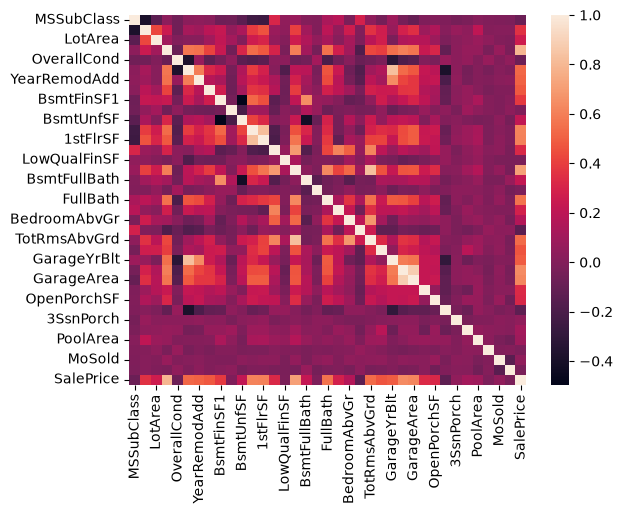

In [96]:
df_temp = df_train.select_dtypes(include=["int", "float"]).drop(columns="Id")
corr_matrix = df_temp.corr()
sns.heatmap(corr_matrix)  # каша

In [97]:
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
sorted_pairs = upper_tri.unstack().dropna().sort_values(ascending=False).reset_index()  # type: ignore
sorted_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]

In [98]:
sorted_pairs[abs(sorted_pairs["Correlation"]) > 0.5]  # заметная корреляция

,Feature_1,Feature_2,Correlation
0,GarageArea,GarageCars,0.882475
1,GarageYrBlt,YearBuilt,0.825667
2,TotRmsAbvGrd,GrLivArea,0.825489
3,1stFlrSF,TotalBsmtSF,0.819530
4,SalePrice,OverallQual,0.790982
5,SalePrice,GrLivArea,0.708624
6,GrLivArea,2ndFlrSF,0.687501
7,TotRmsAbvGrd,BedroomAbvGr,0.676620
8,BsmtFullBath,BsmtFinSF1,0.649212
9,GarageYrBlt,YearRemodAdd,0.642277


In [99]:
sorted_pairs[abs(sorted_pairs["Correlation"]) > 0.7]  # заметная корреляция

,Feature_1,Feature_2,Correlation
0,GarageArea,GarageCars,0.882475
1,GarageYrBlt,YearBuilt,0.825667
2,TotRmsAbvGrd,GrLivArea,0.825489
3,1stFlrSF,TotalBsmtSF,0.819530
4,SalePrice,OverallQual,0.790982
5,SalePrice,GrLivArea,0.708624


In [100]:
df_temp = df_train.select_dtypes(include=["int", "float"]).drop(columns="Id")
corr_series = df_temp.corr()["SalePrice"].drop("SalePrice").sort_values(ascending=False)
corr_series

OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64

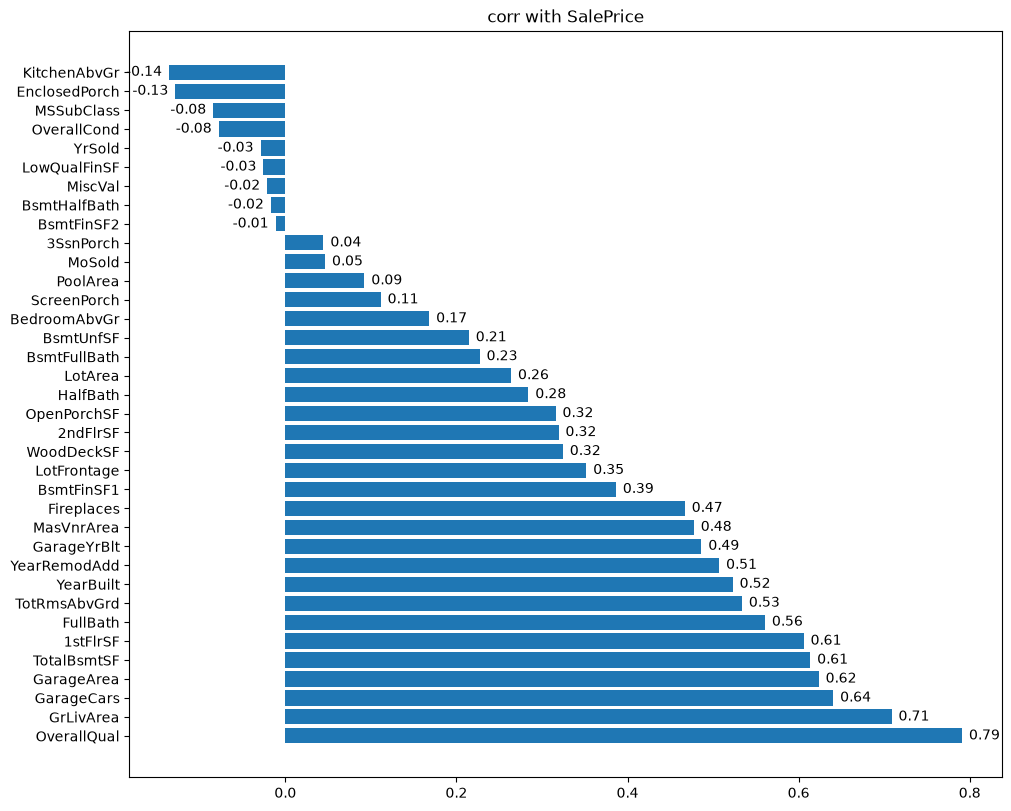

In [101]:
fig, ax = plt.subplots(figsize=(10, 8), layout="constrained")

ax.barh(corr_series.index, corr_series.values)  # type: ignore

ax.set(title="corr with SalePrice")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=5)

<Axes: >

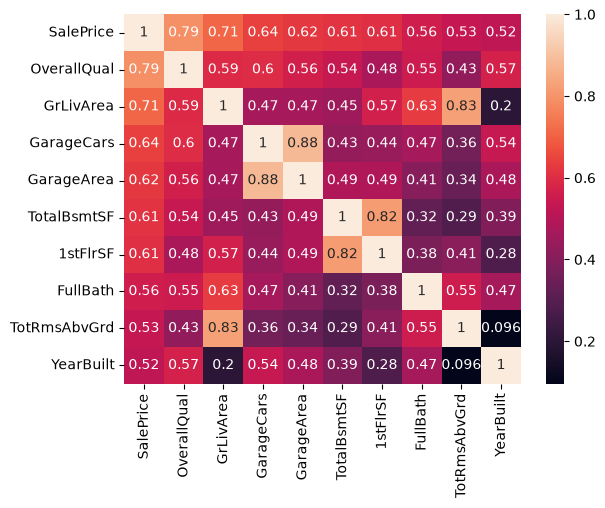

In [102]:
k = 10

cols = corr_matrix.nlargest(k, "SalePrice")["SalePrice"].index
cm = np.corrcoef(df_train[cols].values.T)

sns.heatmap(cm, annot=True, xticklabels=cols.values, yticklabels=cols.values)

SalePrice имеет довольно много заметных корреляций (интересная фича OverallQual, типо качество - прокси фича))
* SalePrice - GarageCars / GarageArea (наличие гаража даже лучше чем подвала)
* OverallQual и GarageCars / GarageArea (чем качественнее дом, тем просторнее гараж)
* OverallQual - YearBuilt (новые дома более качественные)

Мультиколлинеарности:
* TotalBsmtSF: Total square feet of basement area - 1stFlrSF: First Floor square feet (площади подвала и первого этажа связаны)
* GarageCars: Size of garage in car capacity - GarageArea: Size of garage in square feet (измеряют одно и то же просто в разных единицах)
* GrLivArea: Above grade (ground) living area square feet - TotRmsAbvGrd: Total rooms above grade (does not include bathrooms) (жилая площадь и кол-во жилых комнат связаны)
*  GrLivArea: Above grade (ground) living area square feet - FullBath: Full bathrooms above grade (больше жилой площади - больше ванных)

Очень слабые связи:
* YearBuilt - GrLiveArea/ TotRmsAbvGrd (год постройки не влияет на кол-во комнат, разве что немного на размер)

### nans

In [103]:
# информативнее смотреть по всем данным
df_all_data = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)

df_all_data = df_all_data.drop(columns=["SalePrice"])
df_all_data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
2915,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
2916,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
2917,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


In [104]:
all_na = df_all_data.isna().mean().sort_values(ascending=False)
all_na = all_na[all_na > 0]
all_na

PoolQC          0.996574
MiscFeature     0.964029
Alley           0.932169
Fence           0.804385
MasVnrType      0.605002
FireplaceQu     0.486468
LotFrontage     0.166495
GarageYrBlt     0.054471
GarageCond      0.054471
GarageFinish    0.054471
GarageQual      0.054471
GarageType      0.053786
BsmtCond        0.028092
BsmtExposure    0.028092
BsmtQual        0.027749
BsmtFinType2    0.027407
BsmtFinType1    0.027064
MasVnrArea      0.007879
MSZoning        0.001370
BsmtHalfBath    0.000685
Utilities       0.000685
Functional      0.000685
BsmtFullBath    0.000685
BsmtFinSF1      0.000343
Exterior1st     0.000343
TotalBsmtSF     0.000343
BsmtUnfSF       0.000343
BsmtFinSF2      0.000343
SaleType        0.000343
KitchenQual     0.000343
GarageCars      0.000343
GarageArea      0.000343
Electrical      0.000343
Exterior2nd     0.000343
dtype: float64

C:\Users\kochn\AppData\Local\Temp\ipykernel_8396\580564738.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


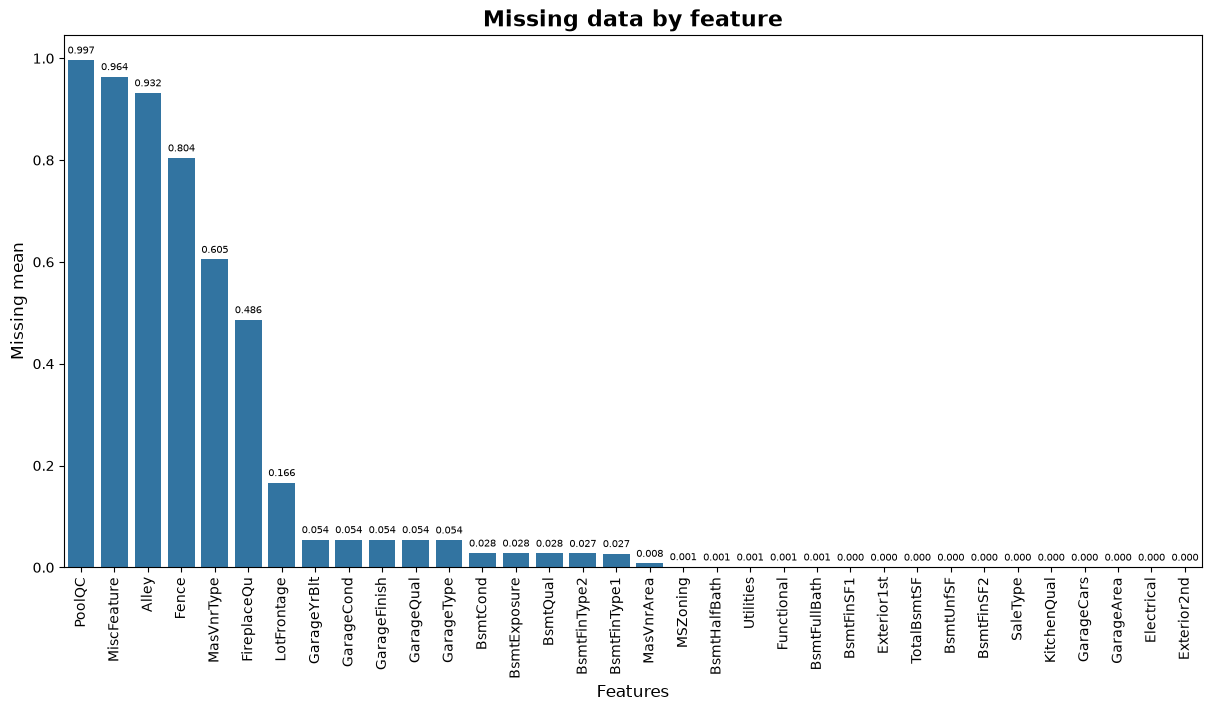

In [105]:
fig, ax = plt.subplots(figsize=(12, 7), layout="constrained")
g = sns.barplot(x=all_na.index, y=all_na.values)
ax.set_title("Missing data by feature", fontsize=16, fontweight="bold")
ax.set_xlabel("Features", fontsize=12)
ax.set_ylabel("Missing mean", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3, fontsize=7)

plt.show()

oe - ordinal encoder
ohe - one hot encoder

Значения Nan
* PoolQC - нет бассейна - пропуск-категория + oe
* MiscFeature - нет особенности - пропуск-категория + ohe
* Alley - нет дорожки - пропуск-категория + ohe
* Fence - нет забора - пропуск-категория + ohe
* MasVnrType - нет обшивки - пропуск-категория + ohe
    
    MasVnrArea - нет обшивки - заполнить 0
* FireplaceQu - нет камина - пропуск-категория + oe
* LotFrontage - преимущественно у необычной LotShape - чем-то заполнить
* GarageQual - пропуск-категория + oe

    GarageFinish - пропуск-категория + oe

    GarageType - пропуск-категория + ohe

    GarageCond- пропуск-категория + oe

    GarageYrBlt - лучше создать отдельный флаг на наличие гаражи и заполнить годом постройки дома

    GarageCars - заполнить нулем

    GarageArea- заполнить нулем
    
    Пропуски в этих колонках из-за отсутствия гаража, [2126, 2576] - баги

* BsmtQual - пропуск-категория - oe

    BsmtCond - пропуск-категория - oe

    BsmtExposure - пропуск-категория - oe

    BsmtFinType1 - пропуск-категория - oe

    BsmtFinType2 - пропуск-категория - oe

    BsmtFinSF1 - заполнить нулем

    BsmtFinSF2 - заполнить нулем

    BsmtUnfSF - заполнить нулем

    TotalBsmtSF - заполнить нулем

    BsmtFullBath - заполнить нулем

    BsmtHalfBath - заполнить нулем

    В большинстве своем пропуск - нет подвала, [332, 948, 1487, 2040, 2185, 2217, 2218, 2348, 2524] - баги + аномалия 2207 в годе

* Electrical - обычный пропуск - чем-то заполнить + ohe
* MSZoning - обычный пропуск - чем-то заполнить  + ohe
* Utilities - обычный пропуск - чем-то заполнить + oe
* Functional - обычный пропуск - чем-то заполнить + oe
* Exterior1st & Exterior2nd - обычный парный пропуск - чем-то заполнить + ohe
* SaleType - обычный пропуск - чем-то заполнить + ohe
* KitchenQual - обычный пропуск - чем-то заполнить + oe

### target

In [106]:
def simple_scatter_plot(
    df: pd.DataFrame, x_col: str, y_col: str, ax=None, figsize: tuple = (7, 4)
):

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize, layout="constrained")
        show_at_the_end = True
    else:
        show_at_the_end = False

    ax.scatter(x=df[x_col], y=df[y_col], alpha=0.5)
    ax.set_title(f"Dependence of {y_col} on {x_col}")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)

    if show_at_the_end:
        plt.show()


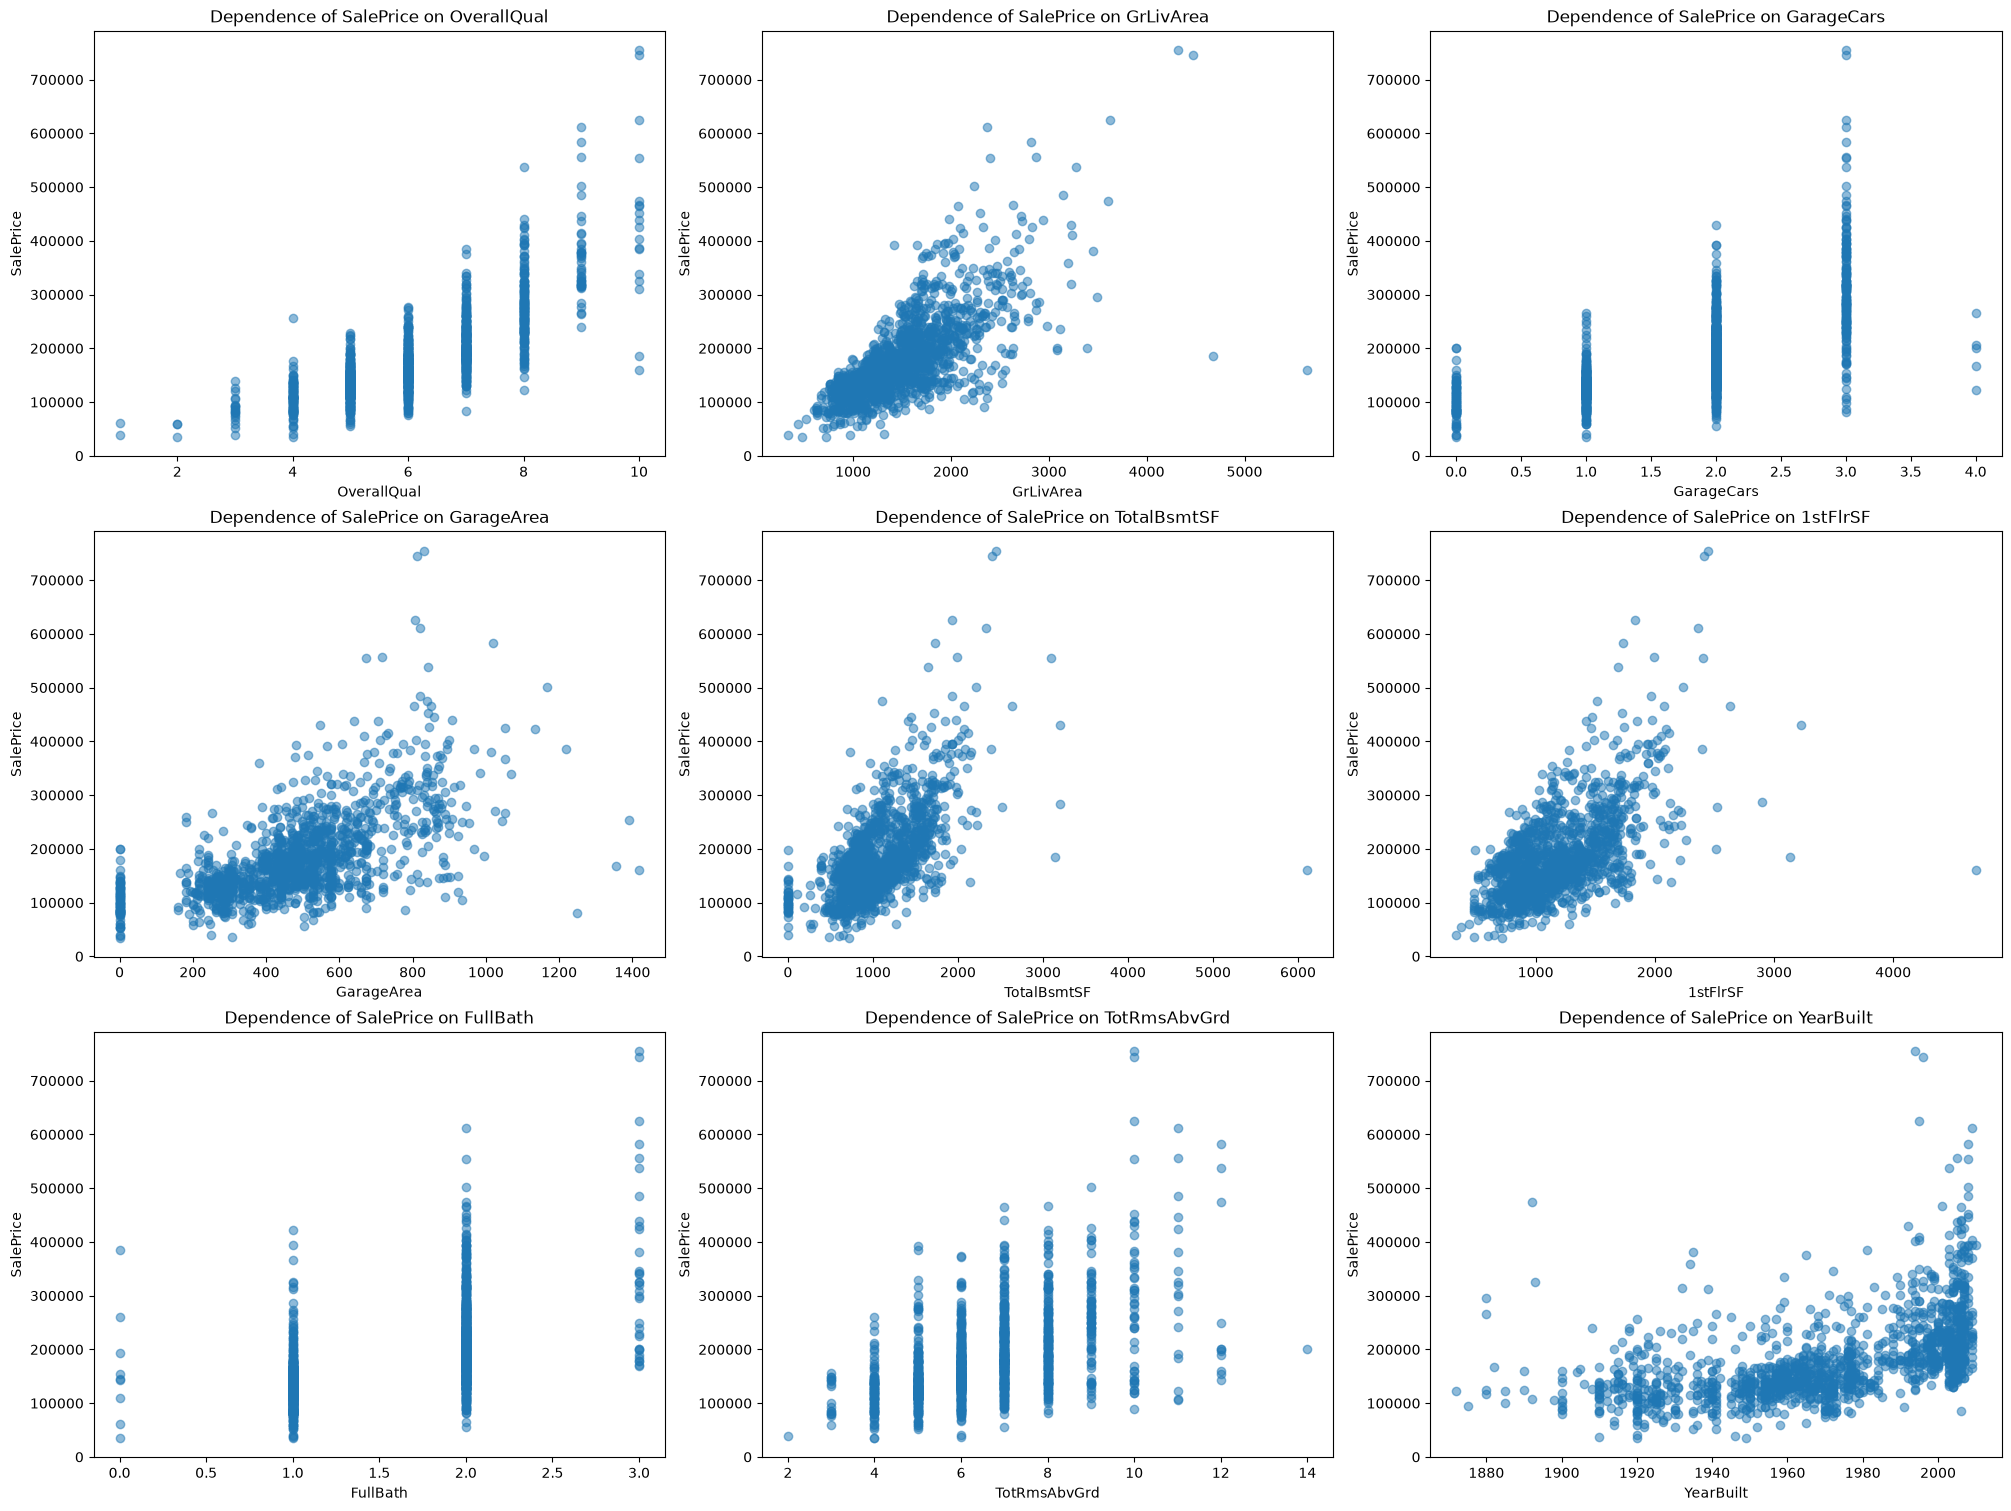

In [107]:
# графики для наиболее скоррелированных фичей с таргетом
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(20, 15), layout="constrained")
features = cols.values[1:]
for i in range(3):
    for j in range(3):
        ind = i * 3 + j

        simple_scatter_plot(
            df_train, x_col=features[ind], y_col="SalePrice", ax=axs[i][j]
        )
plt.show()

In [108]:
# выбросы которые лучше удалить
outliers_grliv = df_train[
    (df_train["GrLivArea"] > 4000) & (df_train["SalePrice"] < 300000)
].index
outliers_bsmt = df_train[
    (df_train["TotalBsmtSF"] > 3000) & (df_train["SalePrice"] < 300000)
].index
print(set(outliers_grliv))
print(set(outliers_bsmt))
print(set(outliers_grliv) & set(outliers_bsmt))

{1298, 523}
{1298, 523, 332}
{1298, 523}


In [109]:
df_train["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [110]:
from scipy import stats
from scipy.stats import norm


In [111]:
def log1p_check(feature, figsize=(20, 12)):
    data = df_train[feature].dropna()
    log_data = np.log1p(data)

    fig, ax = plt.subplots(nrows=2, ncols=2, figsize=figsize, layout="constrained")
    # 1
    sns.histplot(
        data, kde=True, stat="density", label=f"{feature} distribution", ax=ax[0][0]
    )
    mu, sigma = norm.fit(data)
    xmin, xmax = ax[0][0].get_xlim()
    x = np.linspace(xmin, xmax, num=100)
    ax[0][0].plot(x, norm.pdf(x, mu, sigma), "r--", label="Normal distribution")
    ax[0][0].set_title(f"{feature} distribution")
    ax[0][0].legend()
    # 2
    sns.histplot(
        log_data,
        kde=True,
        stat="density",
        label=f"log({feature}) distribution",
        ax=ax[0][1],
    )
    mu, sigma = norm.fit(log_data)
    xmin, xmax = ax[0][1].get_xlim()
    x = np.linspace(xmin, xmax, num=100)
    ax[0][1].plot(x, norm.pdf(x, mu, sigma), "r--", label="Normal distribution")
    ax[0][1].set_title(f"log({feature}) distribution")
    ax[0][1].legend()
    # 3
    stats.probplot(data, dist="norm", plot=ax[1][0])
    ax[1][0].set_title(f"QQ-plot: Original {feature}")
    # 4
    stats.probplot(log_data, dist="norm", plot=ax[1][1])
    ax[1][1].set_title(f"QQ-plot: log({feature})")

    plt.show()

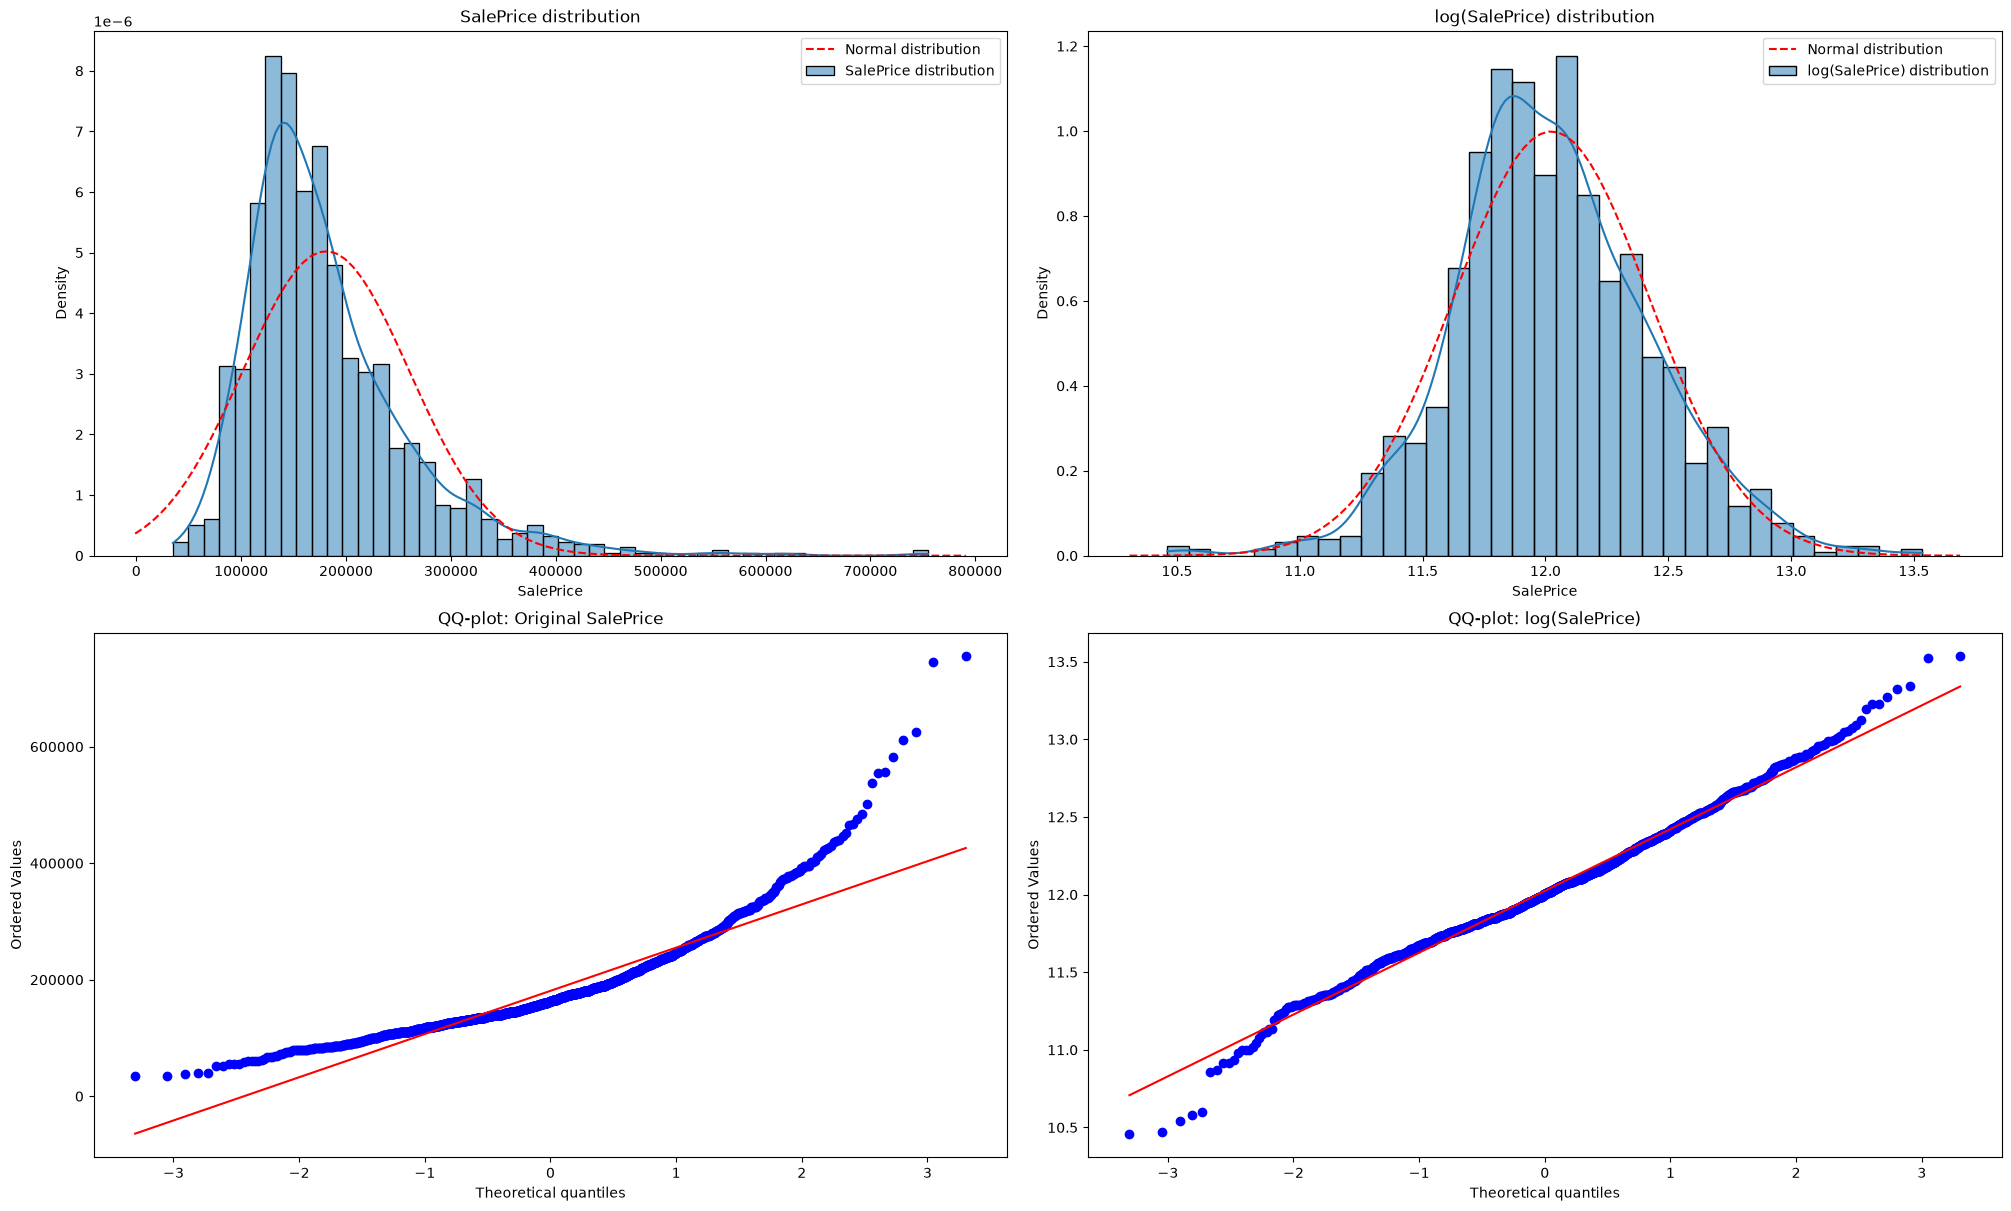

In [112]:
# логарифмированние почти идеально разгладило данные
log1p_check("SalePrice")

### adversarial validation

In [113]:
train_size = df_train.shape[0]

df_adv = df_all_data.copy().drop(columns=["Id"])

X_adv = df_all_data.drop(columns=["Id"])
y_adv = np.concatenate([np.ones(train_size), np.zeros(len(df_all_data) - train_size)])


for col in X_adv.select_dtypes(include=["object", "string"]):
    X_adv[col] = X_adv[col].astype("category")


In [114]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=gseed)

adv_model = LGBMClassifier()

result = cross_validate(adv_model, X_adv, y_adv, cv=cv, scoring="roc_auc")
pd.DataFrame(result)


[LightGBM] [Info] Number of positive: 1168, number of negative: 1167
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001057 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3689
[LightGBM] [Info] Number of data points in the train set: 2335, number of used features: 77
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500214 -> initscore=0.000857
[LightGBM] [Info] Start training from score 0.000857
[LightGBM] [Info] Number of positive: 1168, number of negative: 1167
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000802 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3679
[LightGBM] [Info] Number of data points in the train set: 2335, number of used features: 77
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500214 -> initscore=0.000857
[LightGBM] [Info] Start training from score 0.000857
[LightGBM] [Info] Numb

,fit_time,score_time,test_score
0,0.111779,0.011991,0.494124
1,0.082641,0.011949,0.515962
2,0.087615,0.011834,0.504902
3,0.085592,0.012390,0.492476
4,0.083506,0.011109,0.509191


In [115]:
adv_model.fit(X_adv, y_adv)
importances = pd.Series(
    adv_model.feature_importances_, index=X_adv.columns
).sort_values(ascending=False)
importances.head(15)

[LightGBM] [Info] Number of positive: 1460, number of negative: 1459
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000909 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3776
[LightGBM] [Info] Number of data points in the train set: 2919, number of used features: 77
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500171 -> initscore=0.000685
[LightGBM] [Info] Start training from score 0.000685


LotFrontage     227
LotArea         207
GrLivArea       201
BsmtUnfSF       186
GarageArea      165
1stFlrSF        148
GarageYrBlt     141
BsmtFinSF1      140
MasVnrArea      138
OpenPorchSF     124
TotalBsmtSF     123
MoSold          119
WoodDeckSF      111
YearRemodAdd     88
YearBuilt        83
dtype: int32

Все в порядке, данные train и test не различимы между собой

### numeric features

In [116]:
df_num = df_all_data.select_dtypes(include=["float64", "int64"]).drop(columns="Id")
df_num.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,60,65.0,8450,7,5,2003,2003,196.0,706.0,0.0,...,548.0,0,61,0,0,0,0,0,2,2008
1,20,80.0,9600,6,8,1976,1976,0.0,978.0,0.0,...,460.0,298,0,0,0,0,0,0,5,2007
2,60,68.0,11250,7,5,2001,2002,162.0,486.0,0.0,...,608.0,0,42,0,0,0,0,0,9,2008
3,70,60.0,9550,7,5,1915,1970,0.0,216.0,0.0,...,642.0,0,35,272,0,0,0,0,2,2006
4,60,84.0,14260,8,5,2000,2000,350.0,655.0,0.0,...,836.0,192,84,0,0,0,0,0,12,2008


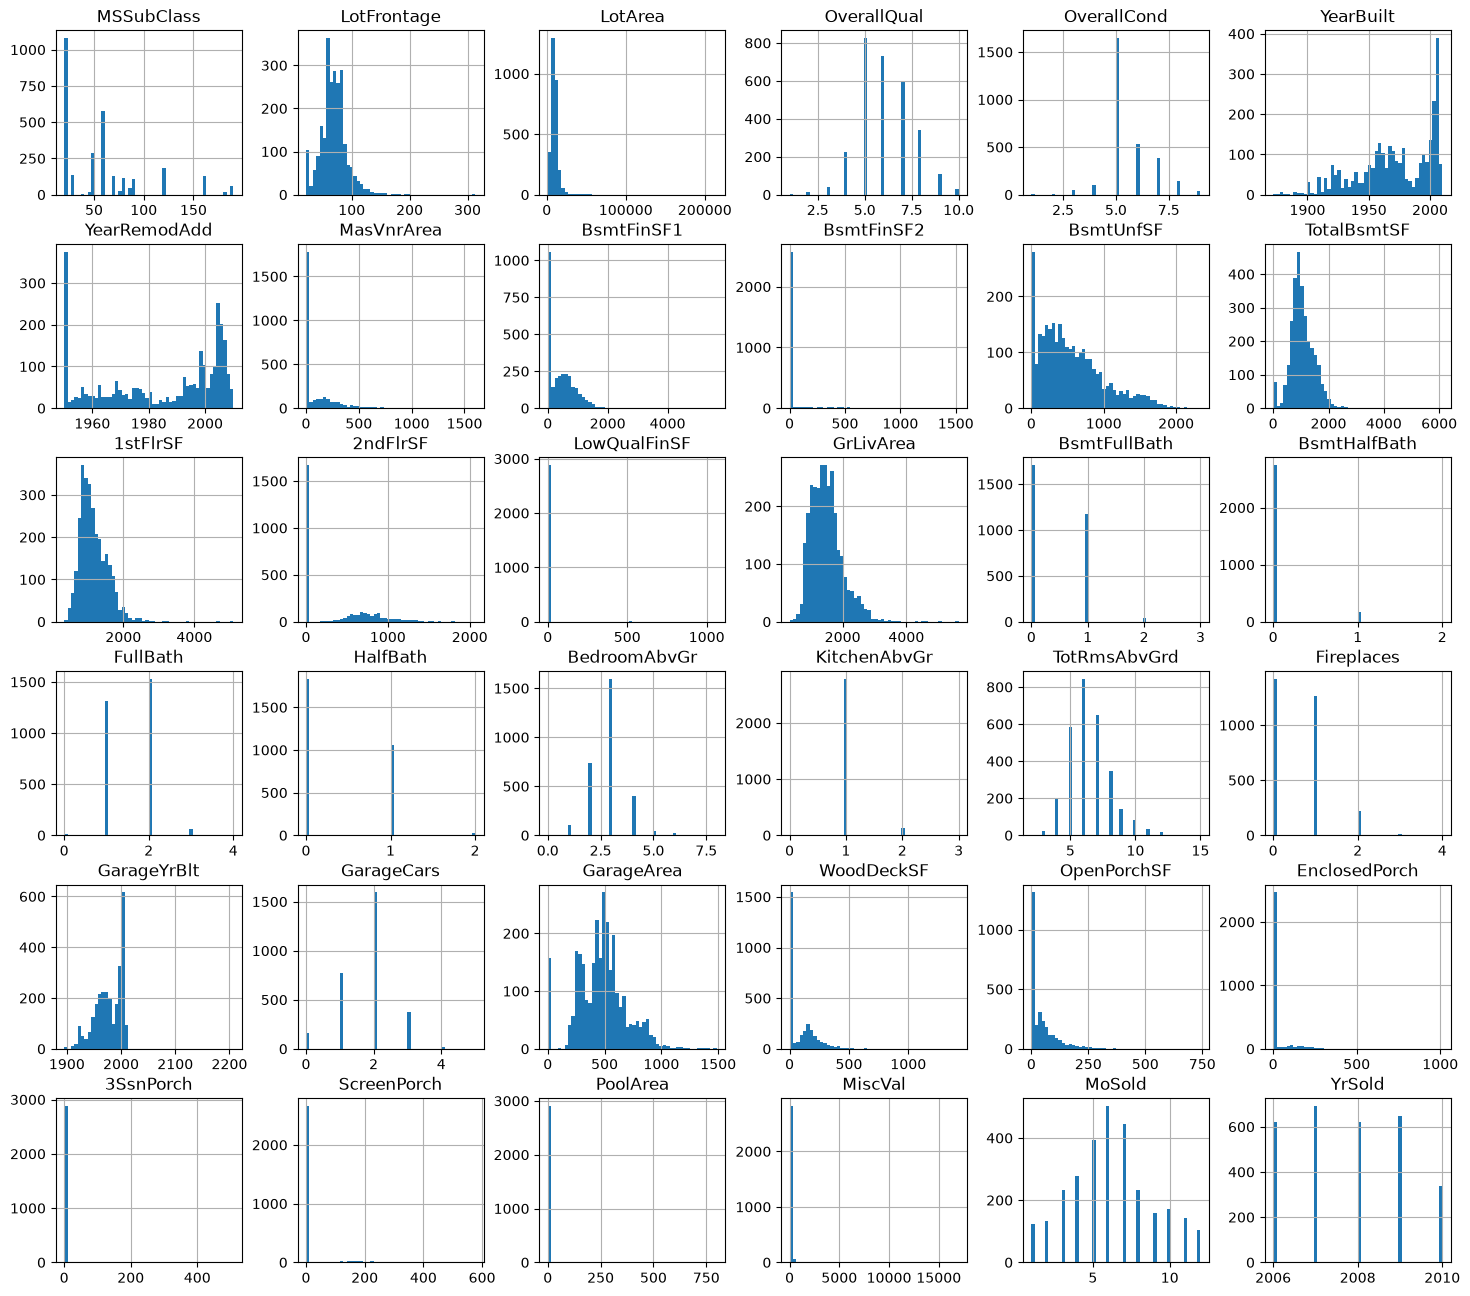

In [117]:
df_num.hist(figsize=(18, 16), bins=50)
picture_path = Path(cfg.paths.pictures)

plt.savefig(picture_path / "histograms.png", dpi=300, bbox_inches="tight")

plt.show()

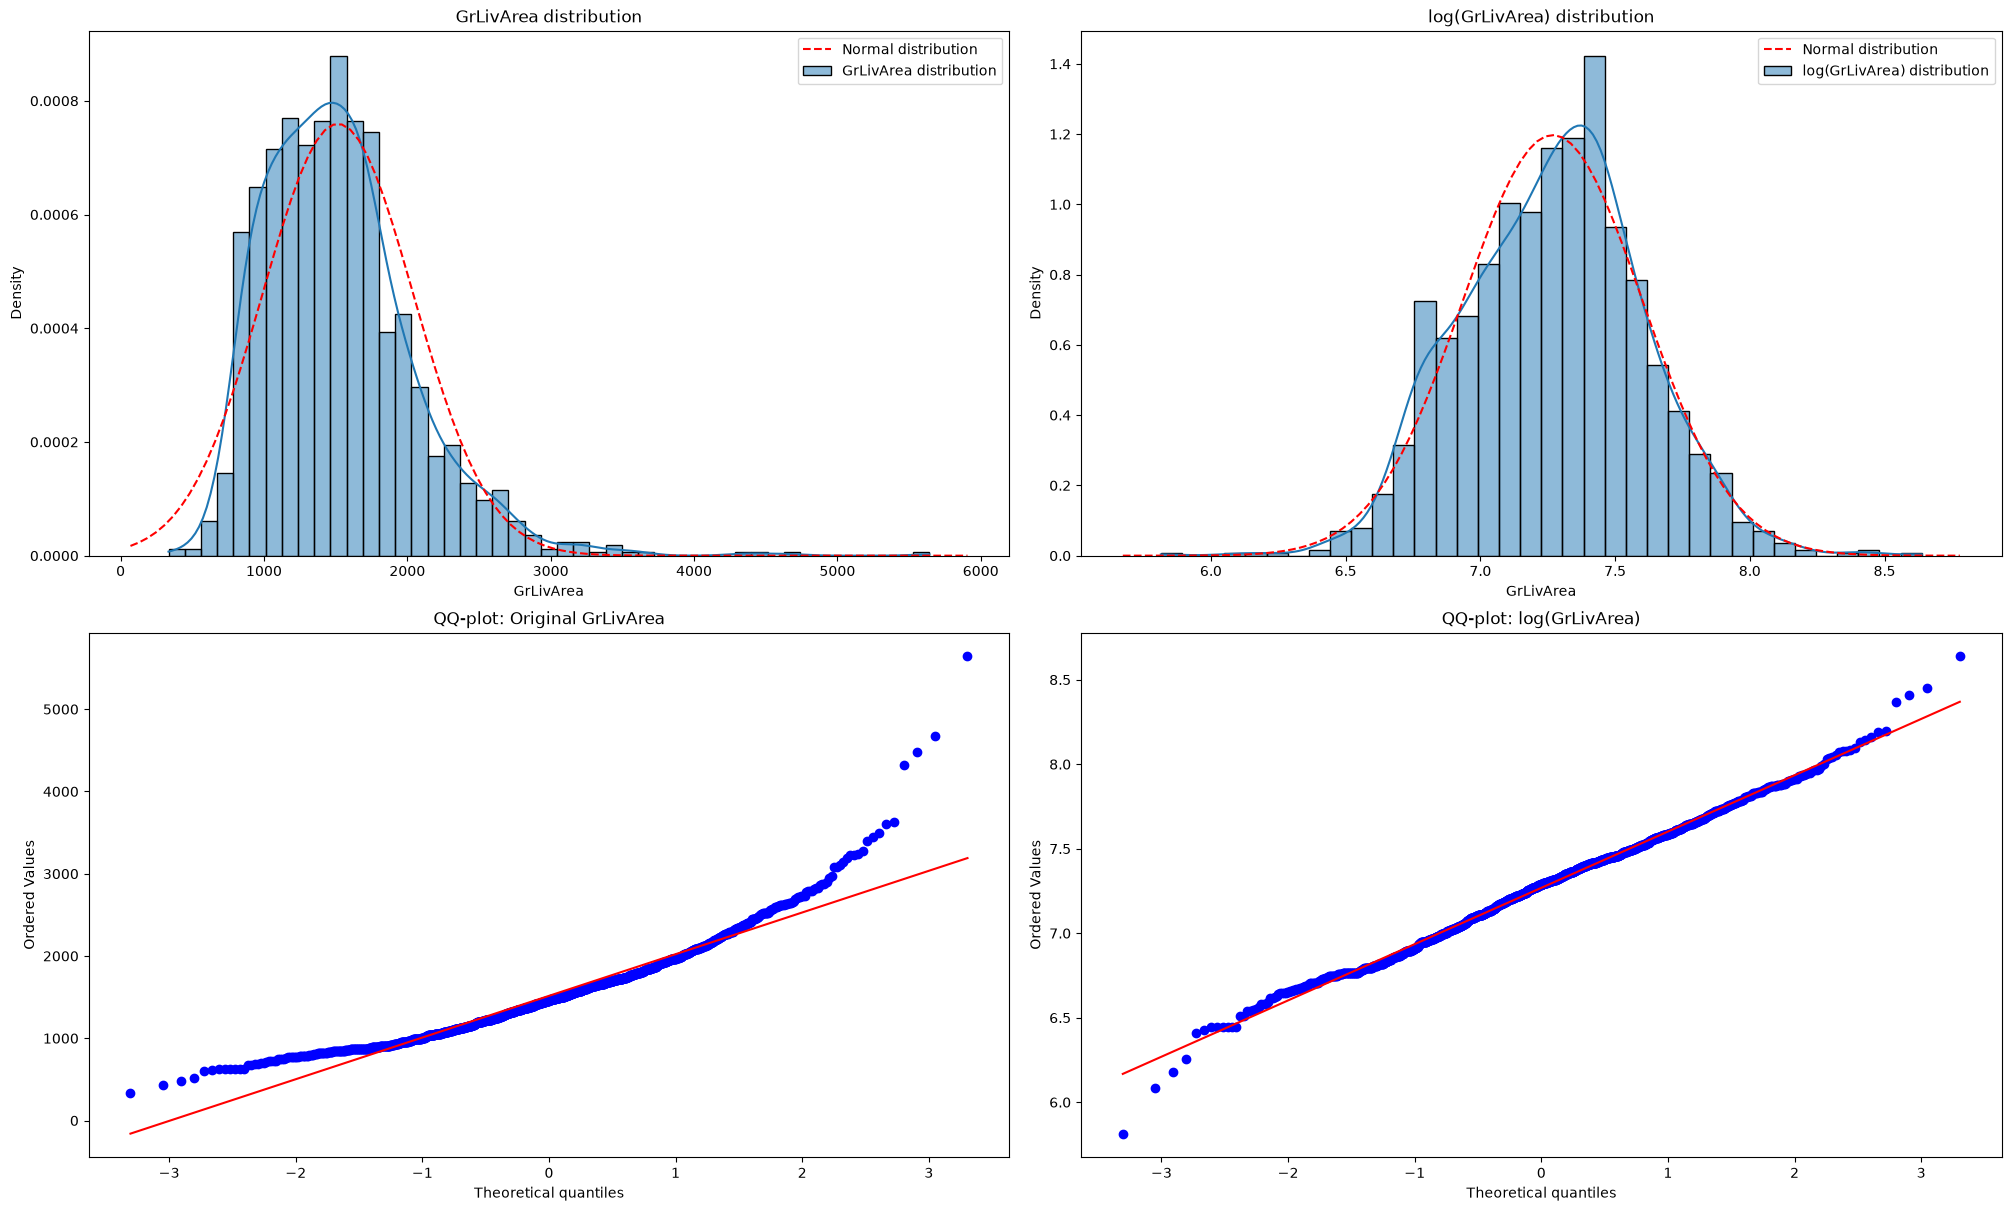

In [118]:
log1p_check("GrLivArea")  # стоит прологарифмировать

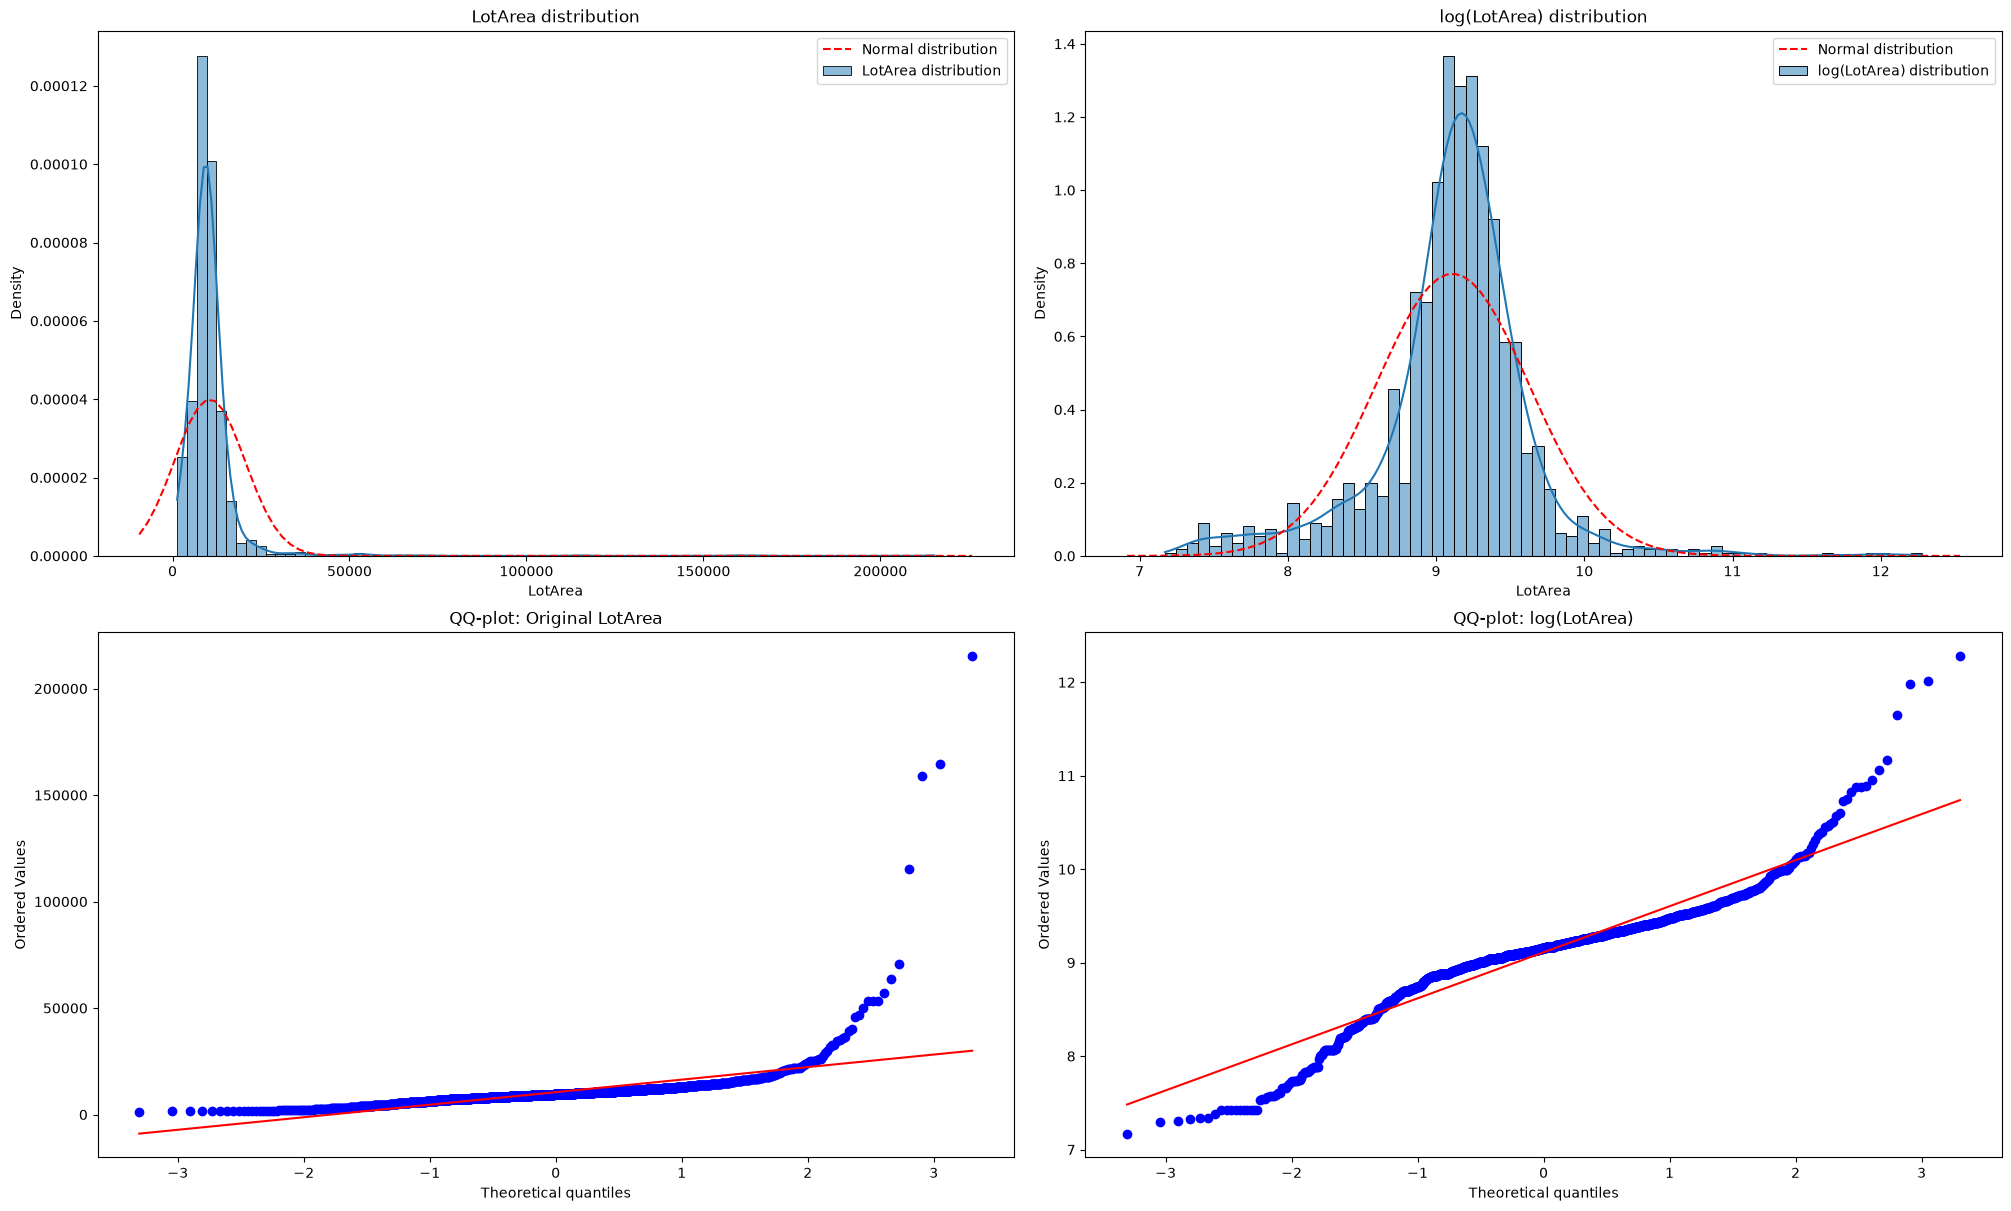

In [119]:
log1p_check("LotArea")  # стоит прологарифмировать

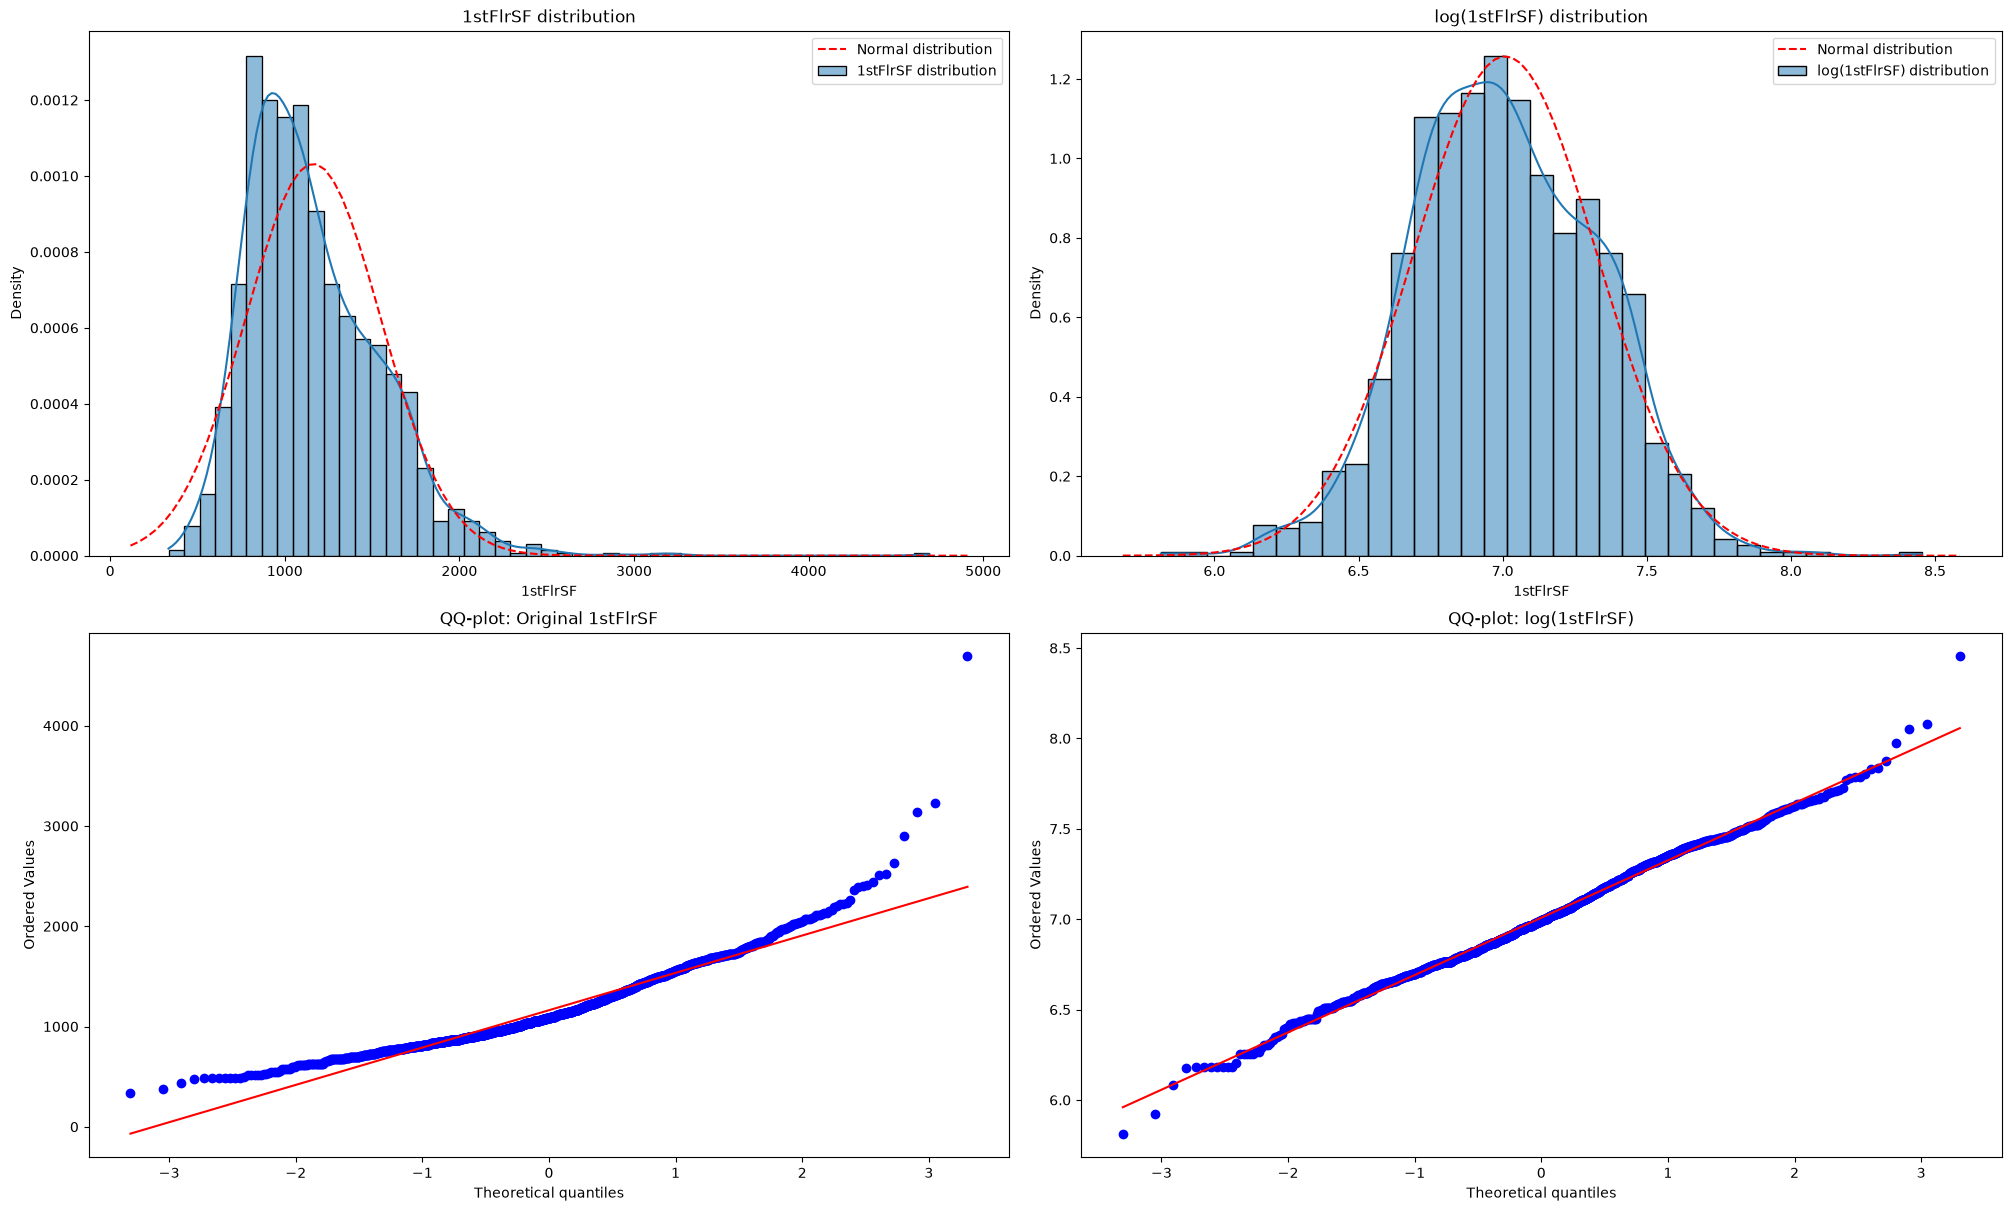

In [120]:
log1p_check("1stFlrSF")  # логарифмирование помогло

Визуально логарифмирование помогает:
* SalePrice
* GrLivArea
* LotArea
* 1stFlrSF

Возрастные колонки лучше рассматривать относительно, ведь их абсолютные значения не так уж и полезны

Идеи:
* MSSubClass - категория + ohe
* MoSold - закодировать через sin/cos для цикличности

### cat features

In [ ]:
# идея для продвинутого imputer, использовать каскадно
print(df_all_data["Neighborhood"].nunique() * df_all_data["LotConfig"].nunique())
df_all_data.groupby(by=["Neighborhood", "LotConfig"])["LotFrontage"].agg(["median"])

125


median
Neighborhood LotConfig        
Blmngtn      Inside       43.0
Blueste      CulDSac      24.0
             Inside       24.0
BrDale       Inside       21.0
BrkSide      Corner       51.0
...                        ...
Timber       Inside       80.0
Veenker      Corner       95.0
             CulDSac      30.0
             FR2          80.0
             Inside       94.0

[87 rows x 1 columns]

In [ ]:
df_all_data["MSSubClass"].value_counts()

MSSubClass
20     1079
60      575
50      287
120     182
30      139
70      128
160     128
80      118
90      109
190      61
85       48
75       23
45       18
180      17
40        6
150       1
Name: count, dtype: int64

In [ ]:
df_all_data["MSSubClass"] = df_all_data["MSSubClass"].astype(str)

In [126]:
df_cat = df_all_data.select_dtypes(include=["object", "str"])

<Axes: xlabel='MSSubClass'>

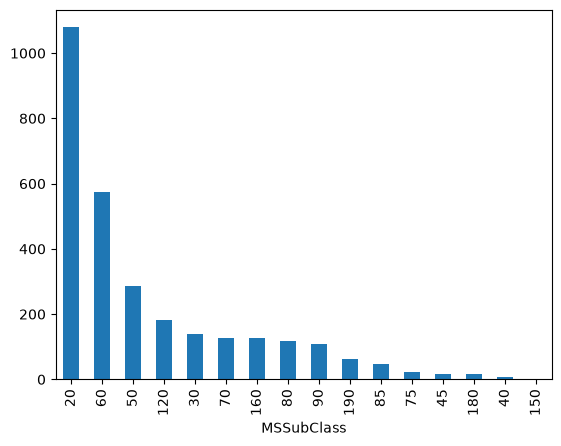

In [ ]:
df_all_data["MSSubClass"].value_counts().plot(kind="bar")

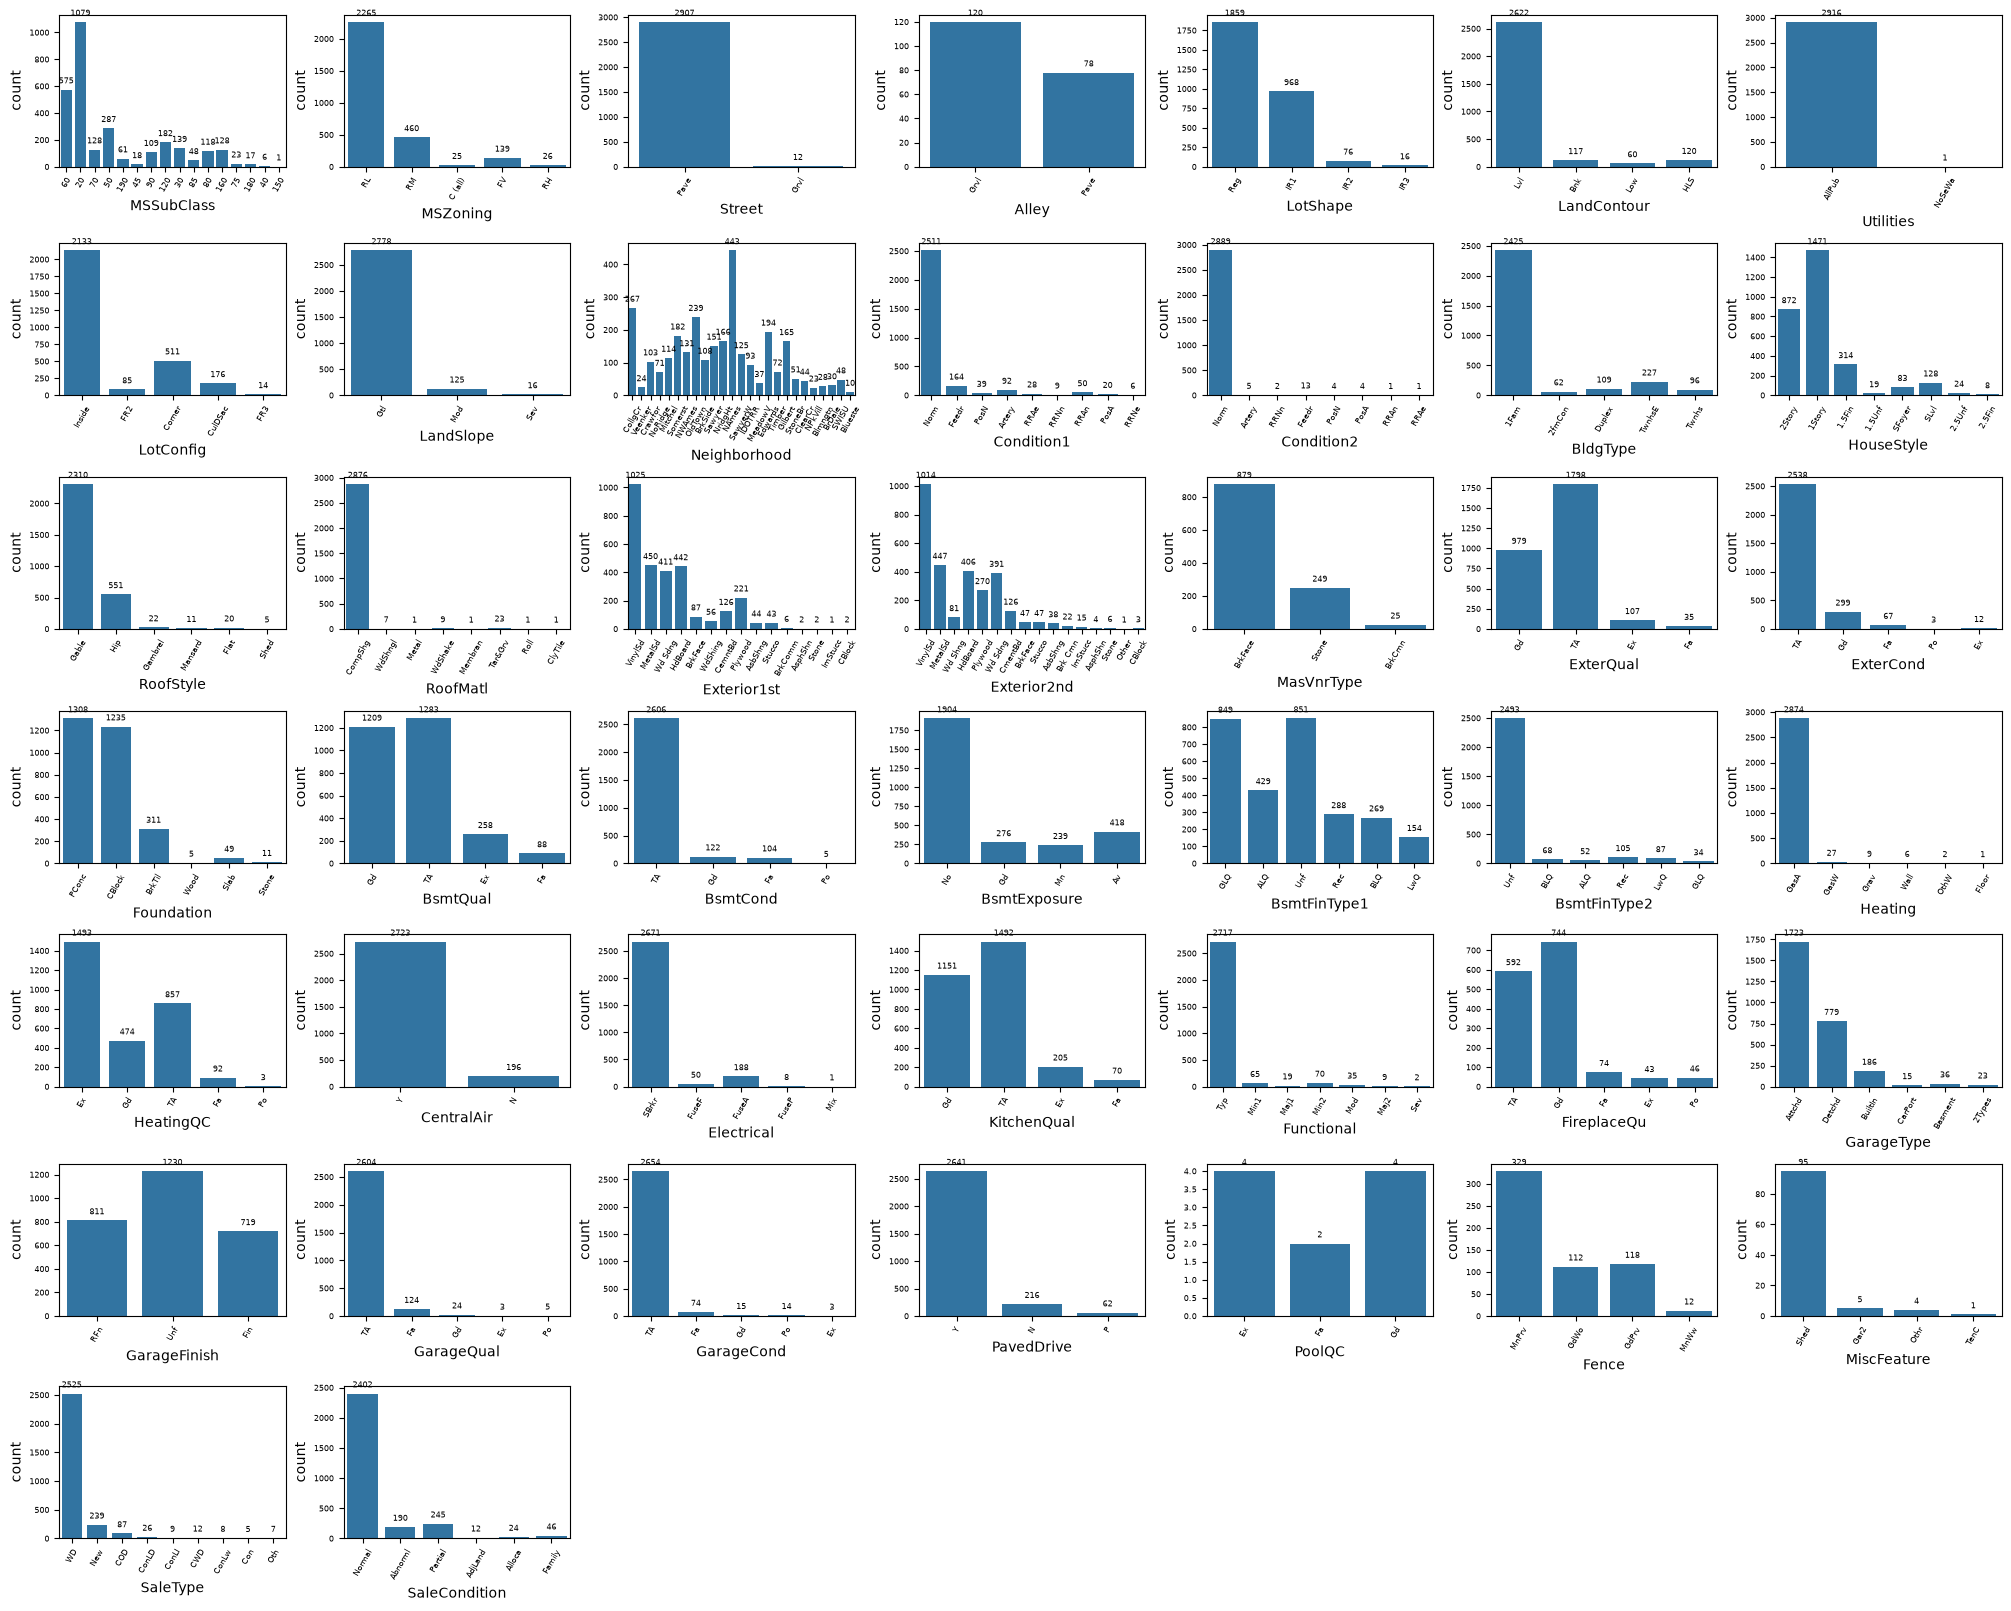

In [ ]:
fig, axes = plt.subplots(nrows=7, ncols=7, figsize=(20, 16), layout="constrained")
axes = axes.flatten() if len(df_cat.columns) > 1 else [axes]

for ax, col in zip(axes, df_cat.columns):
    g = sns.countplot(data=df_cat, x=col, ax=ax)

    ax.tick_params(axis="x", rotation=60, labelsize=6)
    ax.tick_params(axis="y", labelsize=6)

    for container in ax.containers:
        ax.bar_label(container, fontsize=6, padding=3)

for i in range(len(df_cat.columns), len(axes)):
    fig.delaxes(axes[i])

picture_path = Path(cfg.paths.pictures)

plt.savefig(picture_path / "countplots.png", dpi=400, bbox_inches="tight")

plt.show()


In [138]:
df_all_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


In [ ]:
df_all_data.select_dtypes(include=["int64", "float64"]).head()

,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
0,1,65.0,8450,7,5,2003,2003,196.0,706.0,0.0,...,548.0,0,61,0,0,0,0,0,2,2008
1,2,80.0,9600,6,8,1976,1976,0.0,978.0,0.0,...,460.0,298,0,0,0,0,0,0,5,2007
2,3,68.0,11250,7,5,2001,2002,162.0,486.0,0.0,...,608.0,0,42,0,0,0,0,0,9,2008
3,4,60.0,9550,7,5,1915,1970,0.0,216.0,0.0,...,642.0,0,35,272,0,0,0,0,2,2006
4,5,84.0,14260,8,5,2000,2000,350.0,655.0,0.0,...,836.0,192,84,0,0,0,0,0,12,2008


In [ ]:
df_all_data.select_dtypes(include=["object", "str"]).head()

,MSSubClass,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,60,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,20,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2,60,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
3,70,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Abnorml
4,60,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
